In [1]:
import sys
print(sys.executable)
%load_ext autoreload
%autoreload 2

d:\anaconda3\envs\dl\python.exe


这里采用在MNIST上训练的VQ-VAE模型，将训练集数据编码为indices并保存，再用一个PixelCNN学习生成这些indices。
最后让PixelCNN采样生成indices，丢进VQ-VAE去decode

# 1. 导包+全局变量

### 1.1 导包

In [2]:
import GetData
import Model
import Train

import torch 
from torch.utils.data import TensorDataset,DataLoader
import numpy as np

import matplotlib.pyplot as plt
from tqdm import tqdm


### 1.2 全局变量

In [3]:
EPOCHS=10
PRINT_EPOC=1
BATCH_SIZE=128
lr=2e-4
wd=0

device="cuda:0" if torch.cuda.is_available() else "cpu"
IN_CHANNELS=1
HIDDEN_CHANNELS=128
OUT_CHANNELS=1
RESIDUAL_CHANNELS=32
RESIDUAL_LAYERS=2
NUM_EMBEDDINGS=15
EMBEDDING_DIM=64
DECAY=0.99
COMMIT_COST=0.25

# PixelCNN超参数
INPUT_DIM=15
DIM=64
LAYERS=15
N_CLASS=10

mean=[0.0]
std=[1.0]

INDICES_H = 8
INDICES_W = 8


# 2. 加载VQ-VAE模型

In [4]:
# 加载模型：从 checkpoint 读取在Mini-ImageNet上训练得到的最佳模型作为初始权重
import os

CKPT_PATH=r"..\checkpoints\best_vqvae_mnist.pt"
checkpoint=torch.load(CKPT_PATH,map_location=device,weights_only=False)
cfg=checkpoint["config"]

vqvae_model=Model.Model(
    cfg["IN_CHANNELS"],cfg["HIDDEN_CHANNELS"],cfg["OUT_CHANNELS"],
    cfg["RESIDUAL_CHANNELS"],cfg["RESIDUAL_LAYERS"],
    cfg["NUM_EMBEDDINGS"],cfg["EMBEDDING_DIM"],cfg["DECAY"],cfg["COMMIT_COST"]
)
vqvae_model.load_state_dict(checkpoint["model_state_dict"])
vqvae_model=vqvae_model.to(device)

print(f"loaded best mnist model from: {CKPT_PATH}")
print(f"saved best loss: {checkpoint.get('best_loss',float('nan')):.6f}")

loaded best mnist model from: ..\checkpoints\best_vqvae_mnist.pt
saved best loss: 0.003365


# 3. 获取数据加载器 + 生成每个图像的indices

### 3.1 获取原始图像的数据加载器

In [5]:
train_loader,test_loader=GetData.get_MNIST(BATCH_SIZE)

### 3.2 把原始图像变为隐变量

In [7]:

vqvae_model=vqvae_model.to(device)
vqvae_model.eval()

all_indices = []
all_labels = []

with torch.no_grad():
    for loader in [train_loader,test_loader]:
        for images, labels in tqdm(loader, desc=f"生成所有indices"):
            images = images.to(device)
            indices = vqvae_model.encode(images)  # (B, 8, 8)
            all_indices.append(indices.cpu())
            all_labels.append(labels)  # 0-9

all_indices = torch.cat(all_indices, dim=0)
all_labels = torch.cat(all_labels, dim=0)
print(f"生成完成！总共有 {len(all_indices)} 个indices样本")
print(f"每个样本形状：{all_indices.shape[1:]}")  # 应该输出 torch.Size([32, 32])
print(f"标签范围：{all_labels.min().item()} ~ {all_labels.max().item()},"
      f"唯一类别数：{len(torch.unique(all_labels))}")

# 保存到硬盘，下次不用重新生成
torch.save(all_indices, r"..\checkpoints\MNIST_indices_dataset.pt")
torch.save(all_labels, r"..\checkpoints\MNIST_labels_dataset.pt")
print("indices数据集已保存到 CIFAR_indices_dataset.pt")
print("labels数据集已保存到 CIFAR_labels_dataset.pt")

生成所有indices: 100%|██████████| 313/313 [00:02<00:00, 107.54it/s]


生成完成！总共有 70000 个indices样本
每个样本形状：torch.Size([8, 8])
标签范围：0 ~ 9,唯一类别数：10
indices数据集已保存到 CIFAR_indices_dataset.pt
labels数据集已保存到 CIFAR_labels_dataset.pt


### 3.3 把隐变量变为数据加载器

In [6]:
import os
INDICES_PATH = r"..\checkpoints\MNIST_indices_dataset.pt"
LABELS_PATH  = r"..\checkpoints\MNIST_labels_dataset.pt"

def _to_tensor(obj):
    """把加载结果统一规整为 torch.Tensor，兼容 tensor / list / tuple / ndarray。"""
    if isinstance(obj, torch.Tensor):
        return obj
    if isinstance(obj, (list, tuple)):
        if len(obj) == 0:
            raise ValueError("加载得到空的 list/tuple")
        if all(isinstance(x, torch.Tensor) for x in obj):
            return torch.cat(obj, dim=0)
        return torch.as_tensor(obj)
    if isinstance(obj, np.ndarray):
        return torch.from_numpy(obj)
    raise TypeError(f"无法将类型 {type(obj)} 转换为 Tensor")

if os.path.exists(INDICES_PATH) and os.path.exists(LABELS_PATH):
    # weights_only=False: 这些是我们自己存的纯数据，不需要新版默认的安全限制
    all_indices = _to_tensor(torch.load(INDICES_PATH, map_location="cpu", weights_only=False))
    all_labels  = _to_tensor(torch.load(LABELS_PATH,  map_location="cpu", weights_only=False))
    print(f"已从磁盘加载: {INDICES_PATH}, {LABELS_PATH}")
else:
    print("未找到磁盘缓存，使用 3.2 中内存里的 all_indices / all_labels")
    all_indices = _to_tensor(all_indices)
    all_labels  = _to_tensor(all_labels)

# PixelCNN 需要 long 类型的 token indices，分类条件标签也用 long
all_indices = all_indices.long()
all_labels  = all_labels.long()
assert len(all_indices) == len(all_labels), \
    f"indices 与 labels 长度不一致: {len(all_indices)} vs {len(all_labels)}"
n_unique_labels = len(torch.unique(all_labels))
assert n_unique_labels == 10, (
    f"标签仅有 {n_unique_labels} 个唯一值 (期望 100)。"
    "请重新运行上一个 cell 生成带 SPLIT_OFFSET 的全局标签。"
)
assert all_labels.min() >= 0 and all_labels.max() < 10, \
    f"标签超出 [0, 99]: {all_labels.min().item()} ~ {all_labels.max().item()}"
print(f"all_indices: {tuple(all_indices.shape)} {all_indices.dtype}")
print(f"all_labels : {tuple(all_labels.shape)} {all_labels.dtype}")
print(f"标签校验通过: 100 类, 范围 [{all_labels.min().item()}, {all_labels.max().item()}]")

# 划分训练集和验证集（9:1）
perm = torch.randperm(len(all_indices))
all_indices = all_indices[perm]
all_labels  = all_labels[perm]
train_size = int(0.9 * len(all_indices))
train_indices, val_indices = all_indices[:train_size], all_indices[train_size:]
train_labels,  val_labels  = all_labels[:train_size],  all_labels[train_size:]

train_set = TensorDataset(train_indices, train_labels)
valid_set = TensorDataset(val_indices,   val_labels)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"训练集大小：{len(train_indices)}")
print(f"验证集大小：{len(val_indices)}")

已从磁盘加载: ..\checkpoints\MNIST_indices_dataset.pt, ..\checkpoints\MNIST_labels_dataset.pt
all_indices: (70000, 8, 8) torch.int64
all_labels : (70000,) torch.int64
标签校验通过: 100 类, 范围 [0, 9]
训练集大小：63000
验证集大小：7000


# 4. 训练

### 4.1 定义模型

In [9]:
init_model=Model.GatedPixelCNN(
    input_dim=INPUT_DIM,# 512
    dim=DIM,       # 128
    n_layers=LAYERS,            
    n_classes=N_CLASS
)

In [10]:
import os

PRIOR_CKPT_PATH = r"..\checkpoints\best_MNIST_pixelcnn_prior.pt"

if os.path.exists(PRIOR_CKPT_PATH):
    prior_ckpt = torch.load(PRIOR_CKPT_PATH, map_location=device, weights_only=False)
    init_model.load_state_dict(prior_ckpt["model_state_dict"],strict=False)
    init_model = init_model.to(device)
    print(f"已加载已有 PixelCNN prior: {PRIOR_CKPT_PATH}")
    print(f"上次保存的 best val loss: {prior_ckpt.get('best_loss', float('nan')):.6f}")
else:
    print(f"未找到 {PRIOR_CKPT_PATH}, 将从头训练")

未找到 ..\checkpoints\best_MNIST_pixelcnn_prior.pt, 将从头训练


### 4.2 模型训练

In [11]:
train_loss_list,valid_loss_list=[],[]

In [53]:
init_model,train_loss,valid_loss=Train.train_prior(
    init_model,
    train_loader,valid_loader,
    EPOCHS,PRINT_EPOC,
    lr,wd,device,
)
train_loss_list.extend(train_loss)
valid_loss_list.extend(valid_loss)

Epoch 1/10 [train]: 100%|██████████| 493/493 [00:34<00:00, 14.37it/s, loss=0.8634]


epoch: 1
train=0.9211  val=0.9574



Epoch 2/10 [train]: 100%|██████████| 493/493 [00:34<00:00, 14.36it/s, loss=0.9383]


epoch: 2
train=0.9194  val=0.9544



Epoch 3/10 [train]: 100%|██████████| 493/493 [00:34<00:00, 14.11it/s, loss=0.8963]


...

epoch: 8
train=0.9099  val=0.9517



Epoch 9/10 [train]: 100%|██████████| 493/493 [00:33<00:00, 14.70it/s, loss=0.8639]


epoch: 9
train=0.9086  val=0.9514



Epoch 10/10 [train]: 100%|██████████| 493/493 [00:35<00:00, 13.98it/s, loss=0.8584]
                                                                    

epoch: 10
train=0.9070  val=0.9547



In [54]:
best_model=init_model

### 4.3 训练损失可视化

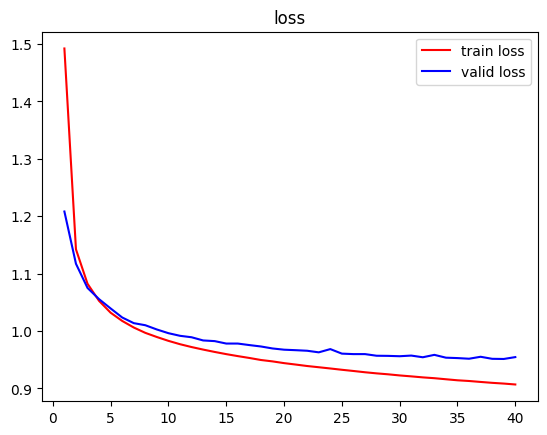

In [55]:
plt.plot(torch.arange(1,4*EPOCHS+1),train_loss_list,"red",label="train loss")
plt.plot(torch.arange(1,4*EPOCHS+1),valid_loss_list,"blue",label="valid loss")
plt.legend()
plt.title("loss")
plt.show()

### 4.4 模型

In [56]:
PRIOR_CKPT_PATH = r"..\checkpoints\best_MNIST_pixelcnn_prior.pt"

prior_cfg = {
    "input_dim": INPUT_DIM,
    "dim":       DIM,
    "n_layers":  LAYERS,
    "n_classes": N_CLASS,
}

best_val_loss = min(valid_loss_list) if len(valid_loss_list) > 0 else float("nan")

if os.path.exists(PRIOR_CKPT_PATH):
    prev_ckpt = torch.load(PRIOR_CKPT_PATH, map_location="cpu", weights_only=False)
    prev_best = prev_ckpt.get("best_loss", float("inf"))
else:
    prev_best = float("inf")

if 1:#best_val_loss < prev_best:
    os.makedirs(os.path.dirname(PRIOR_CKPT_PATH), exist_ok=True)
    torch.save({
        "model_state_dict": best_model.state_dict(),
        "config":           prior_cfg,
        "train_loss_list":  train_loss_list,
        "valid_loss_list":  valid_loss_list,
        "best_loss":        best_val_loss,
    }, PRIOR_CKPT_PATH)
    print(f"已保存新的最佳 PixelCNN prior 到: {PRIOR_CKPT_PATH}")
    print(f"  本次 best val loss: {best_val_loss:.6f}  (此前: {prev_best:.6f})")
else:
    print(f"本次 best val loss = {best_val_loss:.6f} 未优于已保存的 {prev_best:.6f}, 不覆盖")

已保存新的最佳 PixelCNN prior 到: ..\checkpoints\best_MNIST_pixelcnn_prior.pt
  本次 best val loss: 0.951427  (此前: 0.956215)


# 5. 采样

### 5.1 加载最佳先验生成模型

In [7]:
PRIOR_CKPT_PATH = r"..\checkpoints\best_MNIST_pixelcnn_prior.pt"

prior_Model=Model.GatedPixelCNN(
    input_dim=INPUT_DIM,
    dim=DIM,
    n_layers=LAYERS,
    n_classes=N_CLASS
)
if os.path.exists(PRIOR_CKPT_PATH):
    prior_ckpt = torch.load(PRIOR_CKPT_PATH, map_location=device, weights_only=False)
    prior_Model.load_state_dict(prior_ckpt["model_state_dict"])
    prior_Model = prior_Model.to(device)
    print(f"已加载已有 PixelCNN prior: {PRIOR_CKPT_PATH}")
    print(f"上次保存的 best val loss: {prior_ckpt.get('best_loss', float('nan')):.6f}")

已加载已有 PixelCNN prior: ..\checkpoints\best_MNIST_pixelcnn_prior.pt
上次保存的 best val loss: 0.951427


### 5.2 生成标签

In [23]:
labels=torch.tensor([0,1,2,3,4,5,6,7,8,9])
shape=(INDICES_H,INDICES_W)
bs=len(labels)
latent=prior_Model.generate(labels,shape,bs,0.4)



In [17]:
print(latent.shape)
torch.set_printoptions(threshold=float('inf'))
print(latent[2])

torch.Size([10, 8, 8])
tensor([[10, 10, 10, 10,  1,  1, 10, 10],
        [10, 10, 10, 13,  5,  0, 10, 10],
        [10, 10,  1, 14,  3,  7, 10, 10],
        [10, 10,  1,  1, 11,  4,  1, 10],
        [10,  4, 11, 11,  5,  8,  2,  6],
        [ 6,  7,  7,  0,  2,  2,  2, 13],
        [ 4,  5, 13,  1,  1,  1,  1, 10],
        [10,  1, 10, 10, 10, 10, 10, 10]], device='cuda:0')


### 5.3 生成图片

In [24]:
images=vqvae_model.decode(latent)
images=images.cpu().detach()
print(images.shape)
images=images.permute(0,2,3,1)
for i in range(1):  
    images[:,:,:,i]=images[:,:,:,i]*std[i]+mean[i]

torch.Size([10, 1, 32, 32])


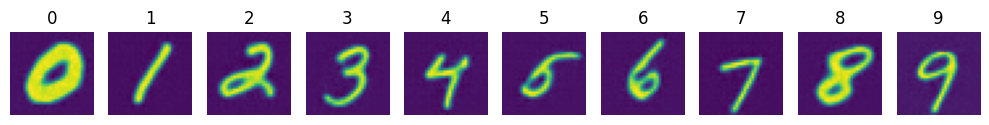

In [25]:
plt.figure(figsize=(10,10))
for i in range(bs):
    plt.subplot(1,bs,i+1)
    plt.imshow(images[i])
    plt.axis("off")
    plt.title(labels[i].item())

plt.tight_layout()
plt.show()